## Stroke Prediction Data Set Analysis

> Joseph Cornell

## Python Packages

Explain a little 

In [12]:
%config InlineBackend.figure_format = 'retina'

In [13]:
# Import packages for numerical computation, statistics, and plotting, and data wrangling
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

print(f'Python {sys.version.split()[0]}')
print(f'numpy {np.__version__}')
print(f'pandas {pd.__version__}')
print(f'scipy {scipy.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'seaborn {sns.__version__}')

Python 3.13.11
numpy 2.4.3
pandas 3.0.1
scipy 1.17.1
matplotlib 3.10.8
seaborn 0.13.2


In [14]:
# Import the required packages to create a linear regression model
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [15]:
# import the required packages for a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [16]:
# Change seaborn and matplotlib to dark style
sns.set_theme(style='dark')

We perform data verification on the data:

1. Shape
2. Information
3. Return first five rows of data

## Data Import and Verification This section goes above Exploratory Data Analysis

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\josep\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [18]:
import os

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Loaded {csv_file} → df shape: {df.shape}")

Loaded healthcare-dataset-stroke-data.csv → df shape: (5110, 12)


In [19]:
# Return the shape of df
(df.shape)

(5110, 12)

The data set contains information about 5110 subjects. The data set consists of 13 variables.

## Introduction

Stroke remains a leading cause of death and long-term disability worldwide, placing a significant burden on individuals, healthcare systems, and public health infrastructure. In the United States alone, stroke is among the top causes of mortality and a major contributor to serious, long-term disability, particularly among older adults and populations with underlying chronic conditions. Despite advances in prevention and treatment, many strokes are still considered preventable through early identification of risk factors such as hypertension, diabetes, smoking, and obesity. As a result, improving early detection and risk stratification has become a central focus in public health and clinical research, with the goal of reducing both incidence and severity of stroke outcomes (Centers for Disease Control and Prevention [CDC], 2023; World Health Organization [WHO], 2022). [CDC/Author](https://www.cdc.gov/stroke/data-research/facts-stats/?CDC_AAref_Val=https://www.cdc.gov/stroke/facts.htm)

In recent years, the emergence of health data science has created new opportunities to enhance stroke prediction through the use of large-scale datasets and advanced analytical techniques. By leveraging electronic health records, population health surveys, and machine learning algorithms, researchers can identify complex patterns and interactions among risk factors that may not be immediately apparent through traditional statistical methods. Predictive modeling allows for the development of tools that can estimate an individual’s likelihood of experiencing a stroke, enabling earlier interventions and more personalized approaches to care. These data-driven methods are particularly valuable in public health settings, where scalable and cost-effective strategies are needed to identify high-risk populations and allocate resources efficiently (Johnson et al., 2021; Khosla et al., 2020).

Johnson, K. W., Torres Soto, J., Glicksberg, B. S., Shameer, K., Miotto, R., Ali, M., & Dudley, J. T. (2021). Artificial intelligence in cardiology. Journal of the American College of Cardiology, 71(23), 2668–2679.

Wrap numbers in dollar signs for example $3-4\%$

## Background \(1-2 pages)

Stroke risk has been widely studied in public health, with research consistently identifying a combination of demographic, behavioral, and clinical factors as key contributors to stroke incidence. Age remains one of the strongest predictors, with risk increasing significantly in older populations due to cumulative vascular damage and comorbid conditions. Gender differences have also been observed, with men generally experiencing higher stroke incidence at younger ages, while women face increased lifetime risk, partly due to longer life expectancy and hormonal factors (Centers for Disease Control and Prevention [CDC], 2023; Virani et al., 2021). These demographic variables provide a foundational understanding of how stroke risk is distributed across populations and are commonly included in predictive models.

Clinical conditions such as hypertension and heart disease are among the most well-established risk factors for stroke, directly contributing to vascular damage and impaired blood flow to the brain. Hypertension, in particular, is considered the leading modifiable risk factor, significantly increasing the likelihood of both ischemic and hemorrhagic stroke. Additionally, metabolic indicators such as elevated blood glucose levels and higher body mass index (BMI) have been linked to increased stroke risk, often through their association with diabetes and cardiovascular disease. Lifestyle and social variables, including marital status, type of employment, and residential environment, have also been explored as indirect indicators of health behaviors, stress levels, and access to healthcare resources, all of which can influence stroke outcomes (O’Donnell et al., 2016; Khosla et al., 2020).

Recent advances in health data science have expanded the ability to analyze these diverse risk factors simultaneously, allowing for more comprehensive and accurate stroke prediction models. Machine learning approaches, in particular, have demonstrated improved performance in identifying complex interactions between variables such as glucose levels, BMI, and pre-existing conditions compared to traditional statistical methods. By incorporating a wide range of features—including demographic characteristics, clinical history, and socioeconomic indicators—these models can better capture the multifactorial nature of stroke risk. As a result, the integration of these variables into predictive analytics frameworks has become a critical area of research, supporting earlier identification of high-risk individuals and more targeted prevention strategies (Johnson et al., 2021; Khosla et al., 2020).

## Methods

explain where you got the data, something about it, and what the columns mean

## Results

a bunch of code and plots

## Exploratory Data Analysis

#### BMI

In [20]:
# Return information about df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [21]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [22]:
df.bmi

0       36.6
1        NaN
2       32.5
3       34.4
4       24.0
        ... 
5105     NaN
5106    40.0
5107    30.6
5108    25.6
5109    26.2
Name: bmi, Length: 5110, dtype: float64

In [23]:
df['bmi'].value_counts()

bmi
28.7    41
28.4    38
27.7    37
26.7    37
26.1    37
        ..
48.1     1
51.7     1
46.3     1
54.1     1
14.9     1
Name: count, Length: 418, dtype: int64

In [24]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [25]:
df.smoking_status.value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

#### Age

In [26]:
df[['age']].describe()

,age
count,5110.000000
mean,43.226614
std,22.612647
min,0.080000
25%,25.000000
50%,45.000000
75%,61.000000
max,82.000000


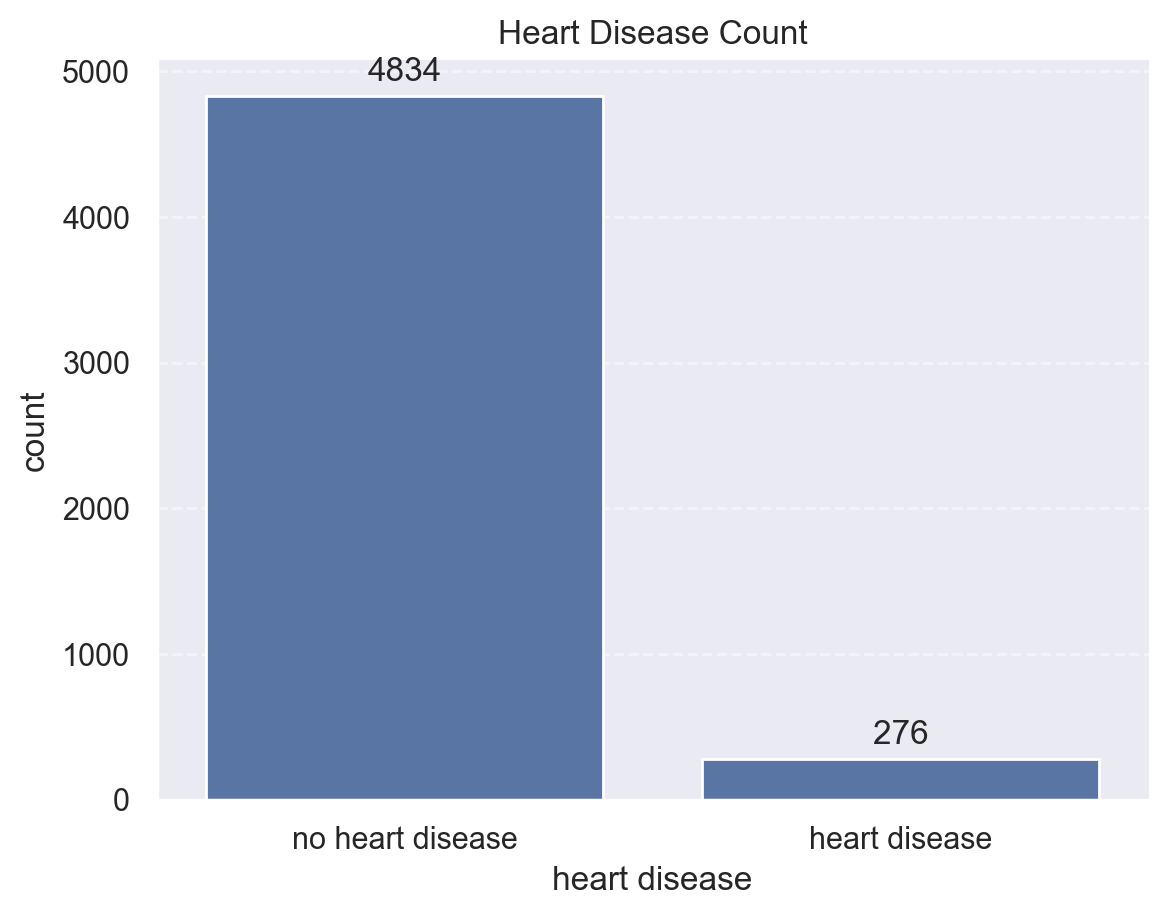

In [27]:
# Use seaborn to create a countplot of the `heart_disease` column
ax = sns.countplot(x='heart_disease', data=df)

# Add title and axis labels
ax.set_title('Heart Disease Count')
ax.set_xlabel('heart disease')
ax.set_xticks([0, 1])
ax.set_xticklabels(['no heart disease', 'heart disease'])

# Remove top and right spines
sns.despine(ax=ax, top=True, right=True)

# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)

# Add frequencies above each bar
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f'{int(height)}',
        (patch.get_x() + patch.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

#### Age

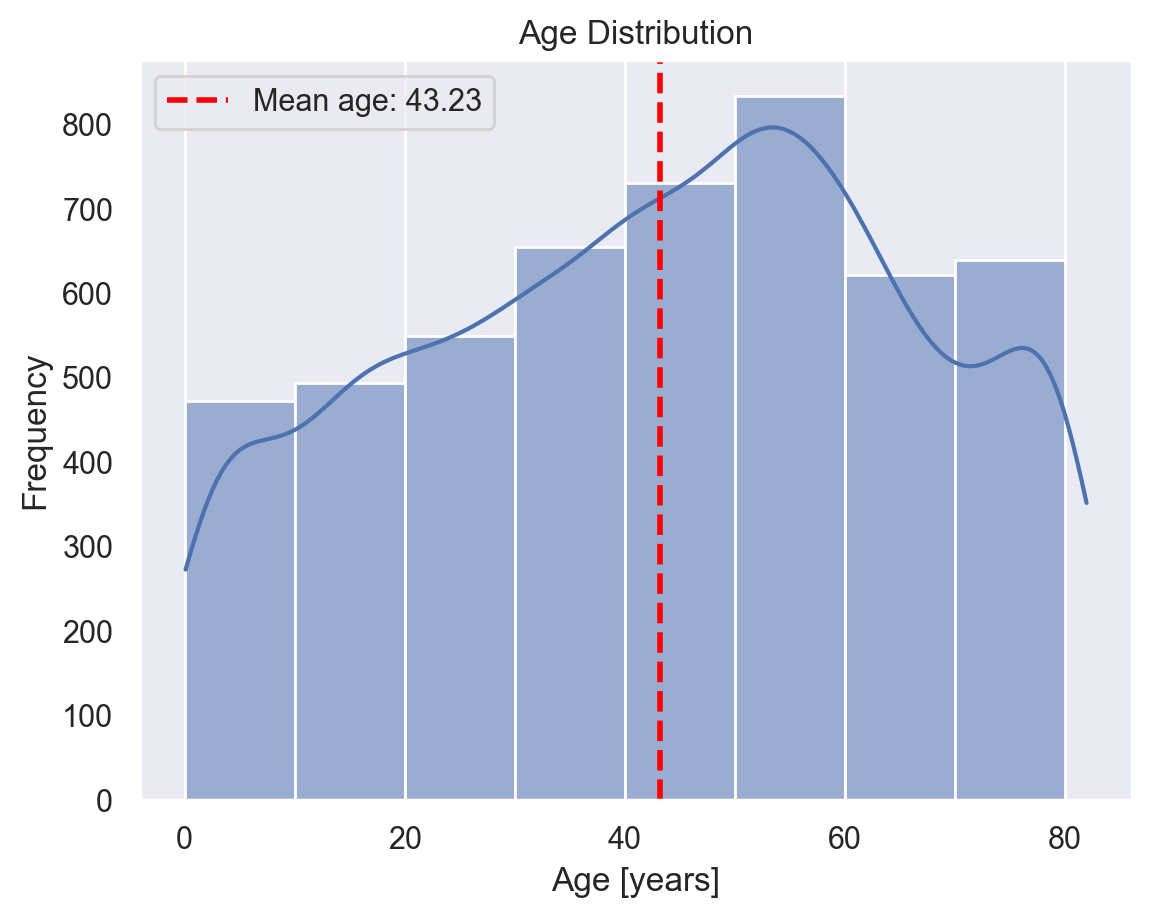

In [28]:
# Create a histogram of the `age` column
# Add the title "Age Distribution"
# Add a horizontal grid to the plot
# Add the horizontal axes label "Age [years]"
# Add the vertical axes label "Frequency"
ax = sns.histplot(x='age', data=df, bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], kde=True)
mean_age = df['age'].mean()
ax.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean age: {mean_age:.2f}')
ax.set_title('Age Distribution')
ax.set_xlabel('Age [years]')
ax.set_ylabel('Frequency')
ax.grid(True, axis='x')
ax.legend()
plt.show()

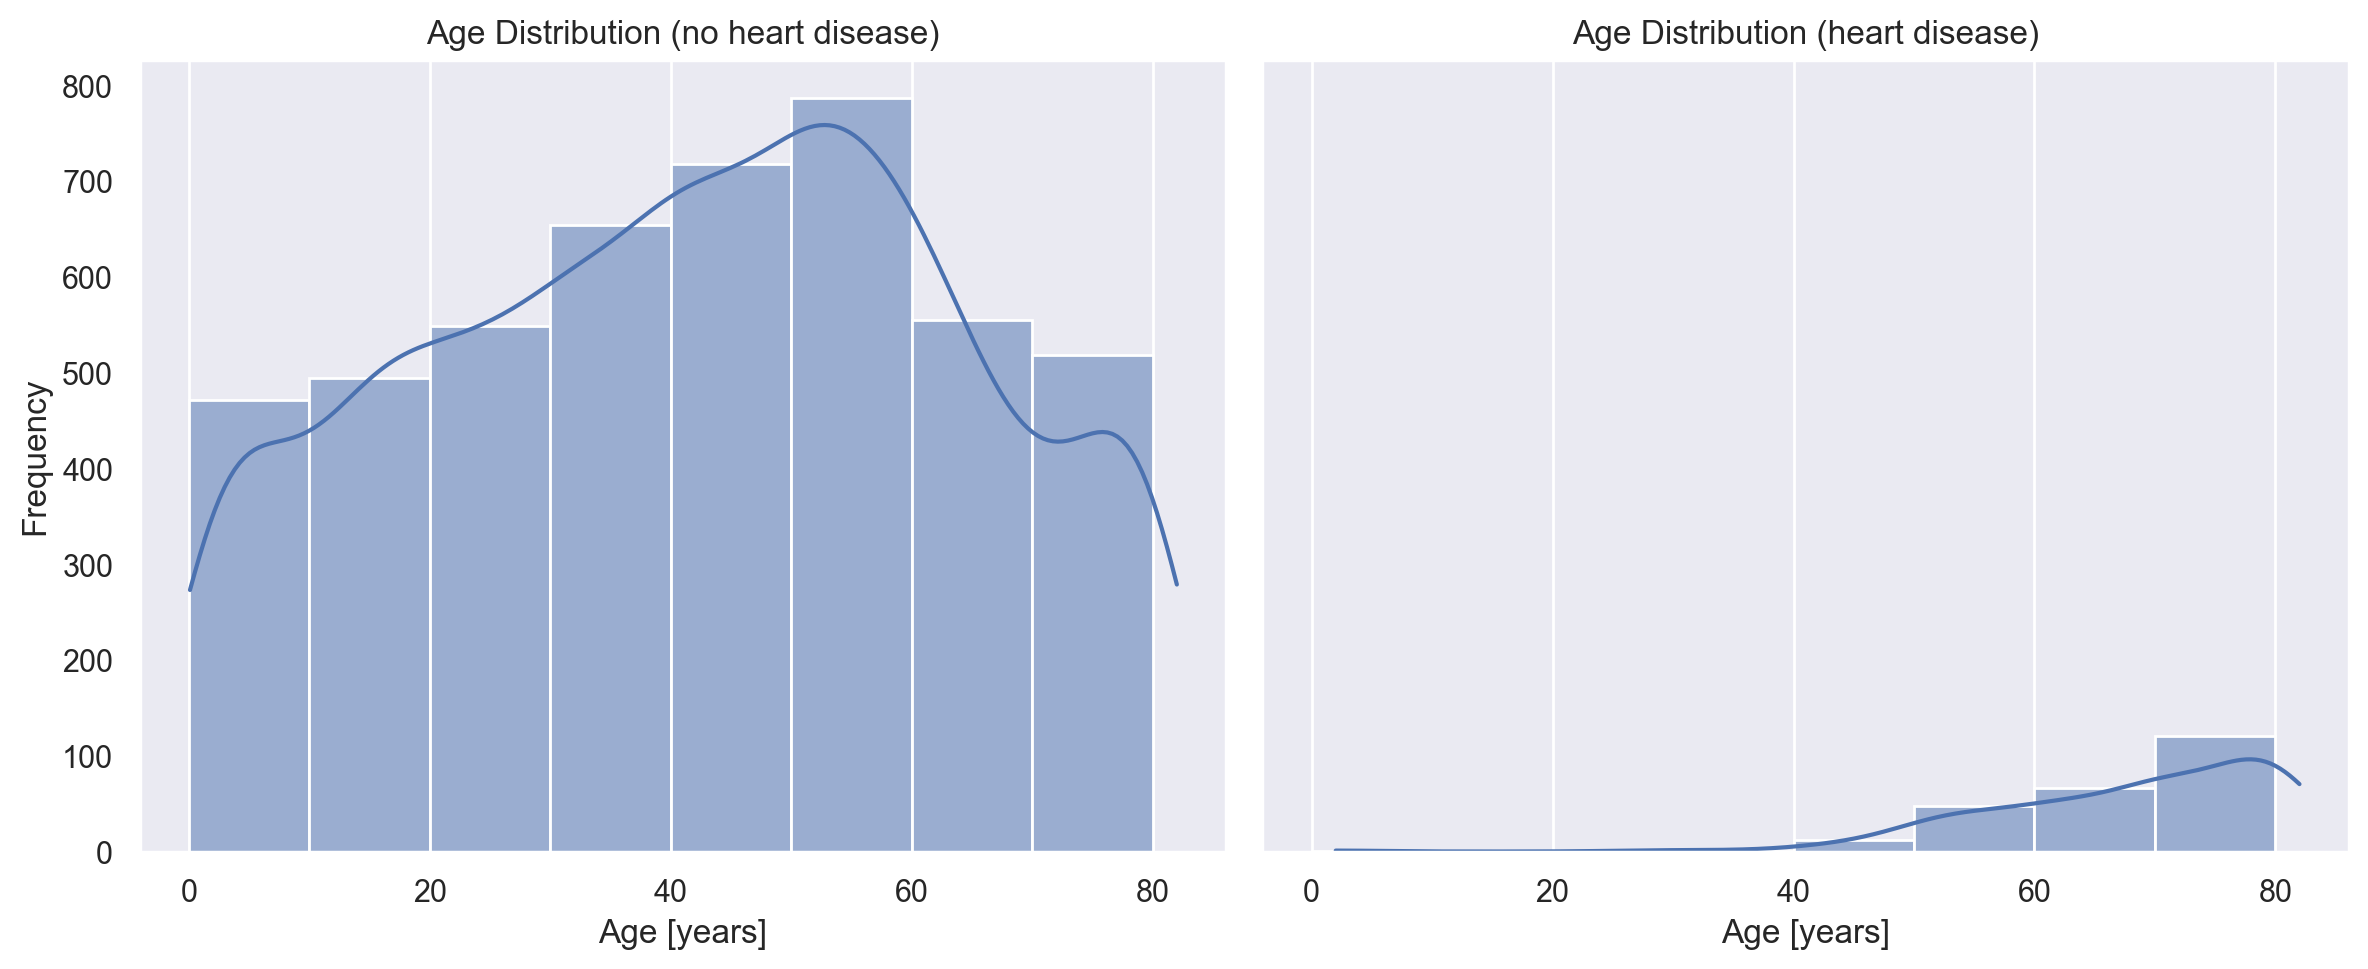

In [29]:
# Recreate the previous histogram, but for each category of the `heart_disease` column
# Create a the two plots with one row and two columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# Plot the histogram of the `age` column for the category of `heart_disease` == 0 in the first plot
sns.histplot(x='age', data=df[df['heart_disease'] == 0], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], kde=True, ax=axes[0])
axes[0].set_title('Age Distribution (no heart disease)')
axes[0].set_xlabel('Age [years]')
axes[0].set_ylabel('Frequency')
# Plot the histogram of the `age` column for the category of `heart_disease` == 1 in the second plot
sns.histplot(x='age', data=df[df['heart_disease'] == 1], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], kde=True, ax=axes[1])
axes[1].set_title('Age Distribution (heart disease)')
axes[1].set_xlabel('Age [years]')
axes[1].set_ylabel('Frequency')
# Add a horizontal grid to both plots
for ax in axes:
    ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

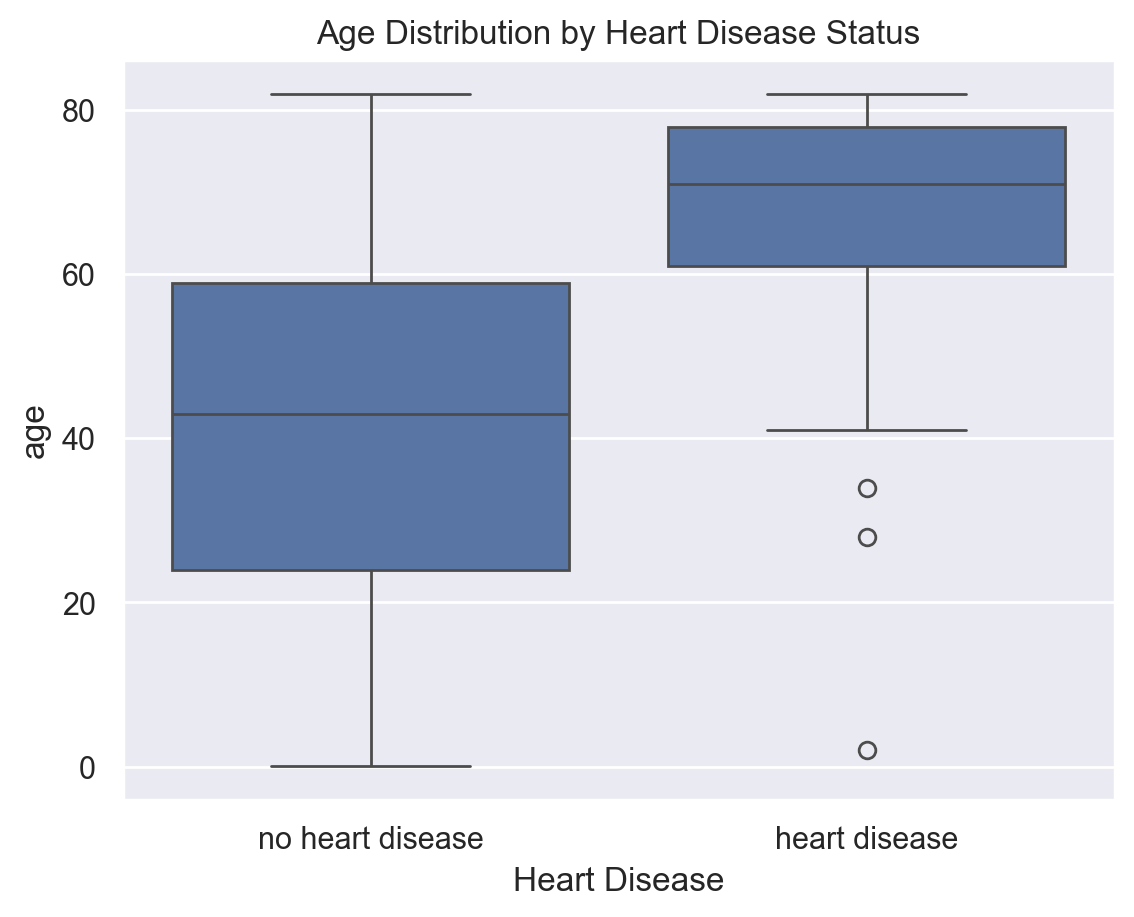

In [30]:
# Create a boxplot of the `age` column for each category of the `heart_disease` column
ax = sns.boxplot(x='heart_disease', y='age', data=df)
ax.set_title('Age Distribution by Heart Disease Status')
ax.set_xlabel('Heart Disease')
ax.set_xticks([0, 1])
ax.set_xticklabels(['no heart disease', 'heart disease'])
ax.grid(True, axis='y')
plt.show()

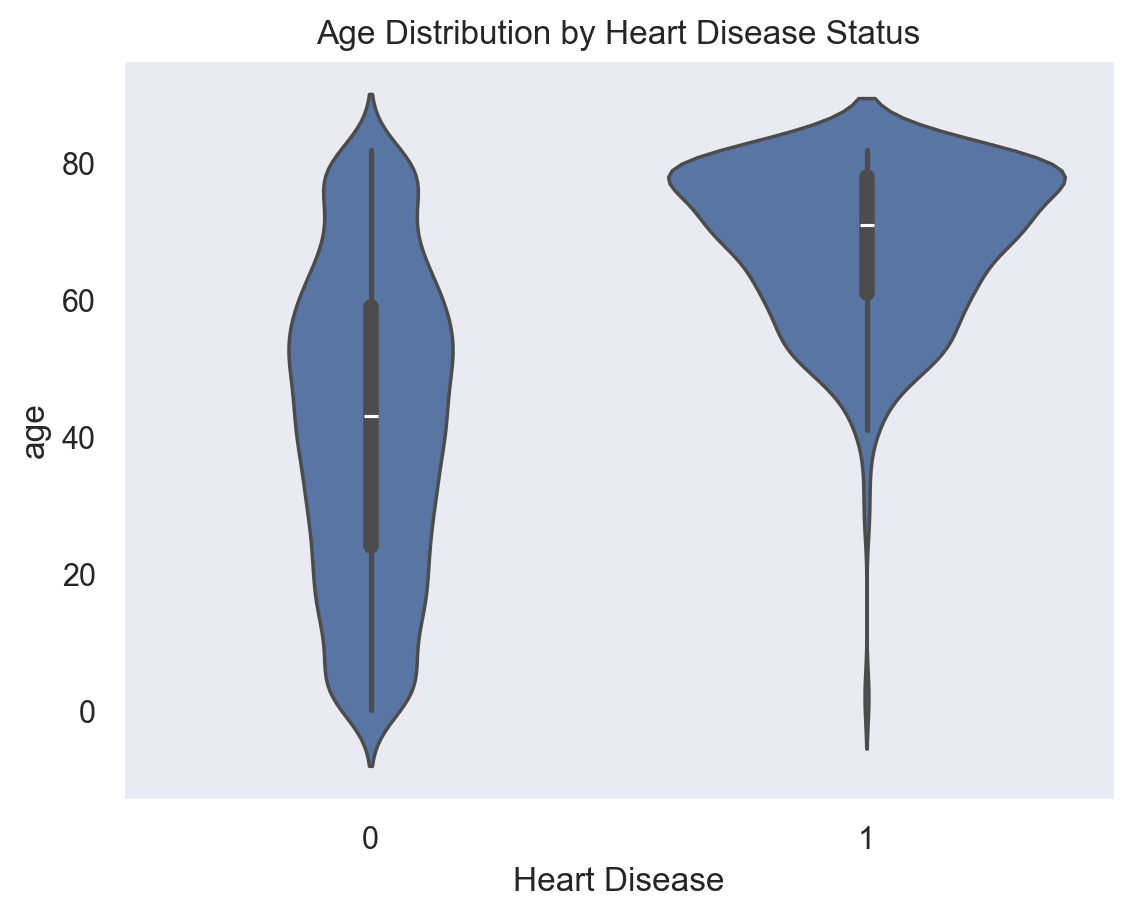

In [31]:
# reproduce the previous boxplot, but as a violin plot
ax = sns.violinplot(x='heart_disease', y='age', data=df)
ax.set_title('Age Distribution by Heart Disease Status')
ax.set_xlabel('Heart Disease')
plt.show()

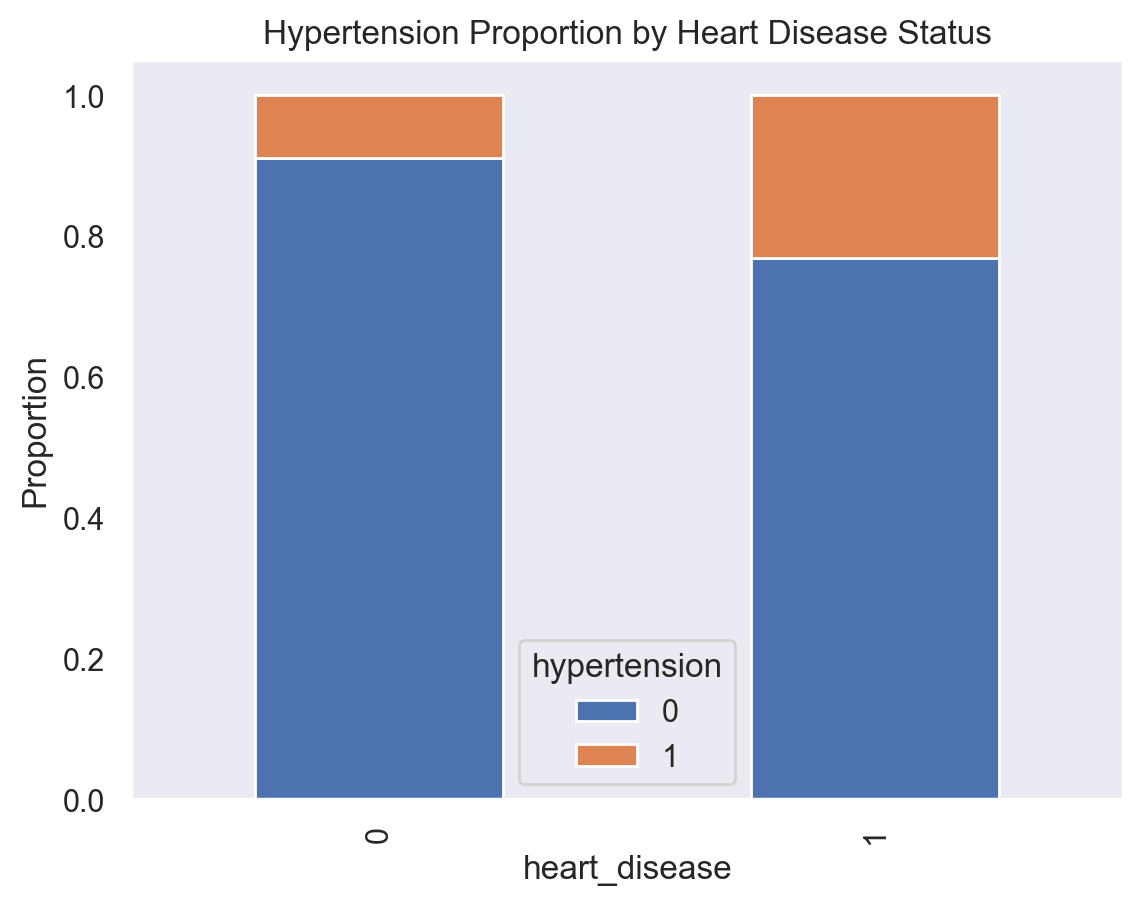

In [32]:
# Create a stacked bar plot of hypertension proportions by heart disease status
proportions = pd.crosstab(df['heart_disease'], df['hypertension'], normalize='index')
ax = proportions.plot(kind='bar', stacked=True)
ax.set_title('Hypertension Proportion by Heart Disease Status')
ax.set_xlabel('heart_disease')
ax.set_ylabel('Proportion')
ax.legend(title='hypertension')
plt.show()

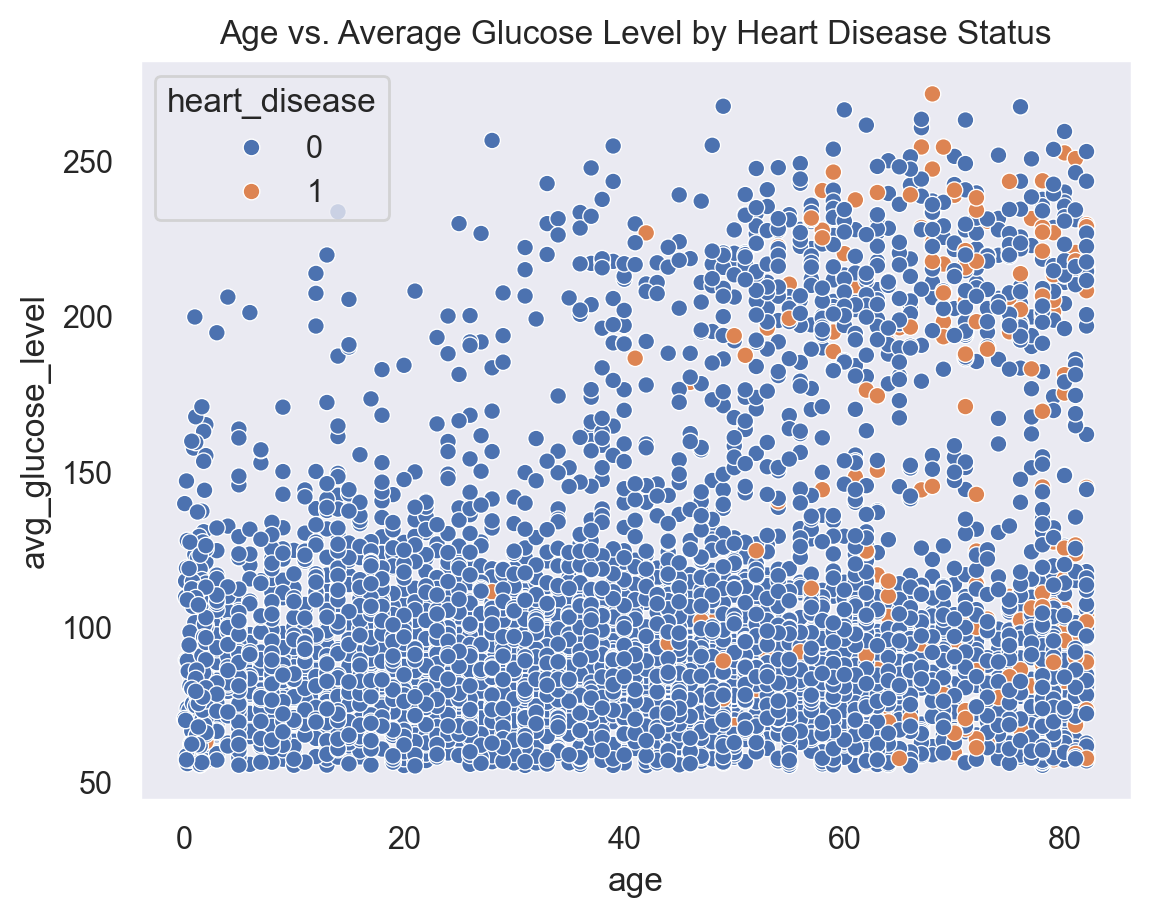

In [33]:
# Create a scatter plot of the 'age' versus 'avg_glucose_level' columns, colored by the 'heart_disease' column
ax = sns.scatterplot(x='age', y='avg_glucose_level', hue='heart_disease', data=df)
ax.set_title('Age vs. Average Glucose Level by Heart Disease Status')
plt.show()

In [47]:
# Create a linear regression model with 'age' as the independent variable and 'avg_glucose_level' as the dependent variable
# Import the libraries needed for this cell so it can run independently
from matplotlib.pyplot import show
import pandas as pd
import statsmodels.api as sm
# Load the dataset from the local CSV file
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
# Use the statsmodels package to fit an ordinary least squares (OLS) regression model
x = df['age'] # independent variable
y = df['avg_glucose_level'] # dependent variable
x_with_const = sm.add_constant(x) # add a constant term to the independent variable
model = sm.OLS(y, x_with_const).fit() # fit the OLS regression

In [41]:
# return as summary of the OLS regression model
print(model.summary())
print('\nP-values:')
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:      avg_glucose_level   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     307.2
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           7.86e-67
Time:                        10:26:31   Log-Likelihood:                -26585.
No. Observations:                5110   AIC:                         5.317e+04
Df Residuals:                    5108   BIC:                         5.319e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         85.5305      1.328     64.427      0.0

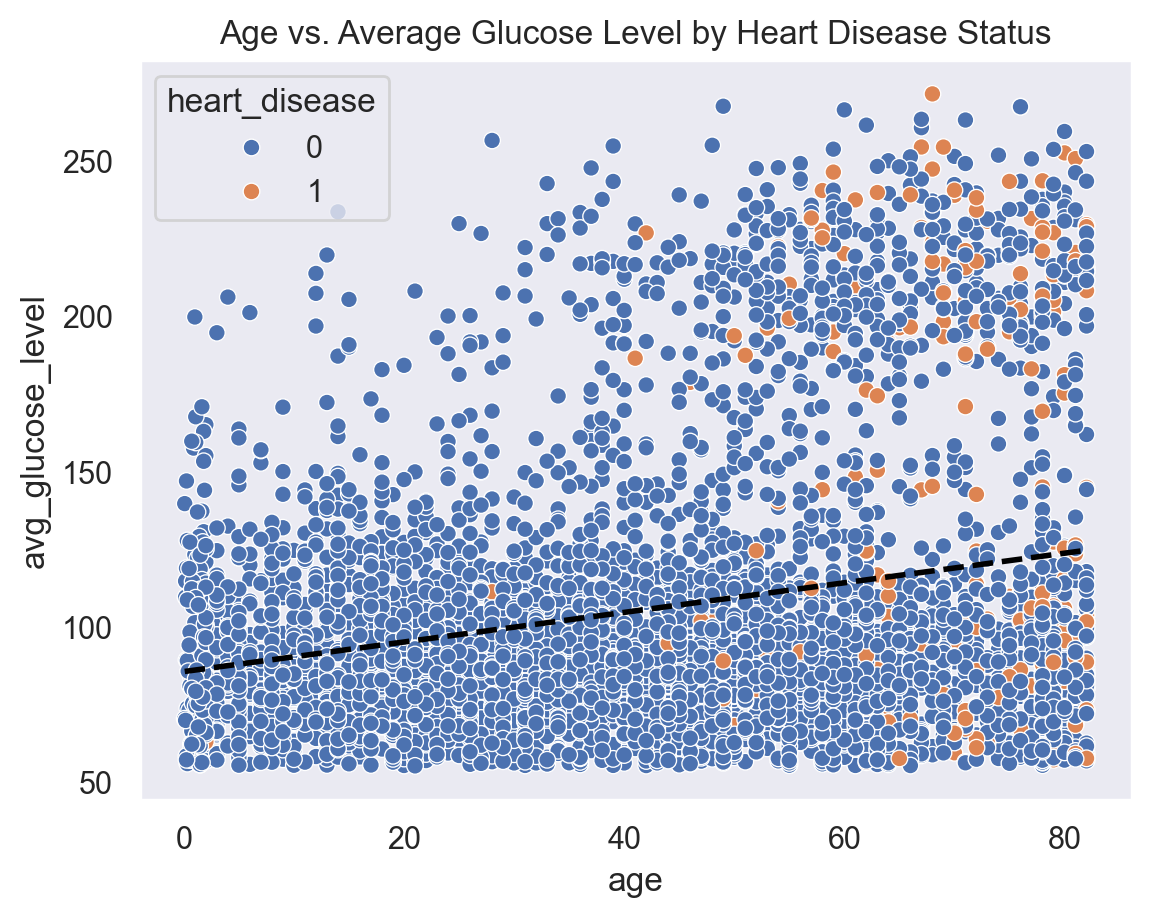

In [43]:
# Recreate the scatterplot of the age versus average glucose level, colored by heart disease status, and add the regression line from the OLS model
ax = sns.scatterplot(x='age', y='avg_glucose_level', hue='heart_disease', data=df)
ax.set_title('Age vs. Average Glucose Level by Heart Disease Status')
# Add the regression line from the OLS model
x_range = np.linspace(df['age'].min(), df['age'].max(), 100)
y_range = model.params['const'] + model.params['age'] * x_range
ax.plot(x_range, y_range, color='black', linestyle='--', linewidth=2)
plt.show()

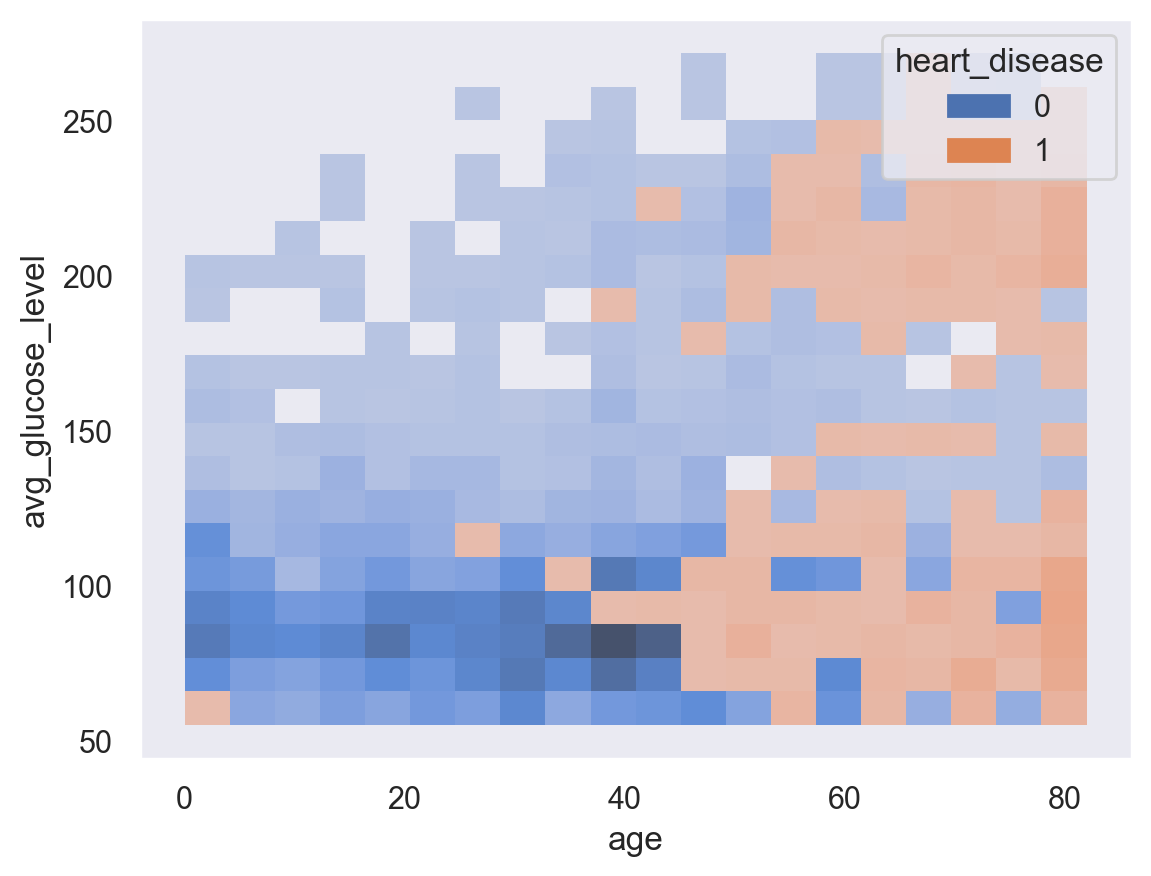

In [35]:
# recreate the scatter plot, but as a heatmap
ax = sns.histplot(x='age', y='avg_glucose_level', hue='heart_disease', data=df, bins=20)
plt.show()

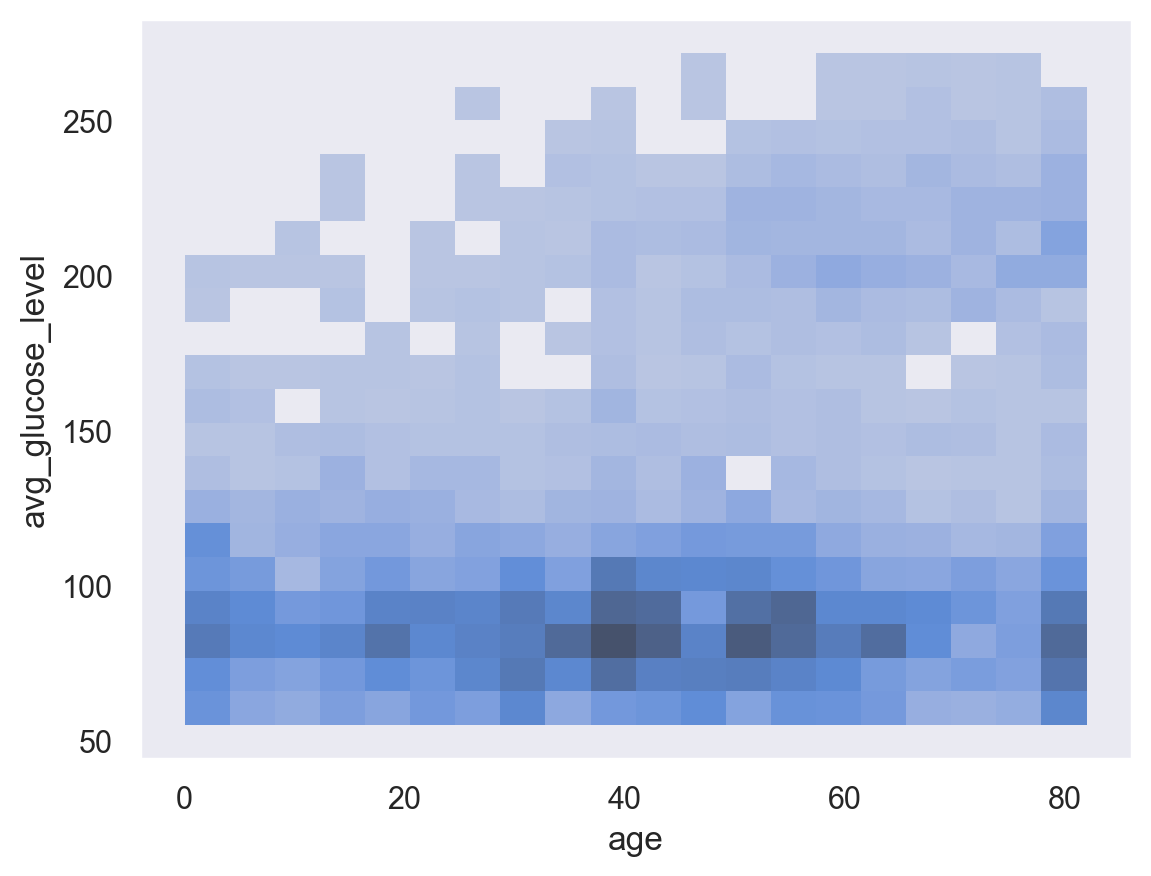

In [36]:
# Create the heat map but exclude the 'heart_disease' column
ax = sns.histplot(x='age', y='avg_glucose_level', data=df, bins=20)
plt.show()

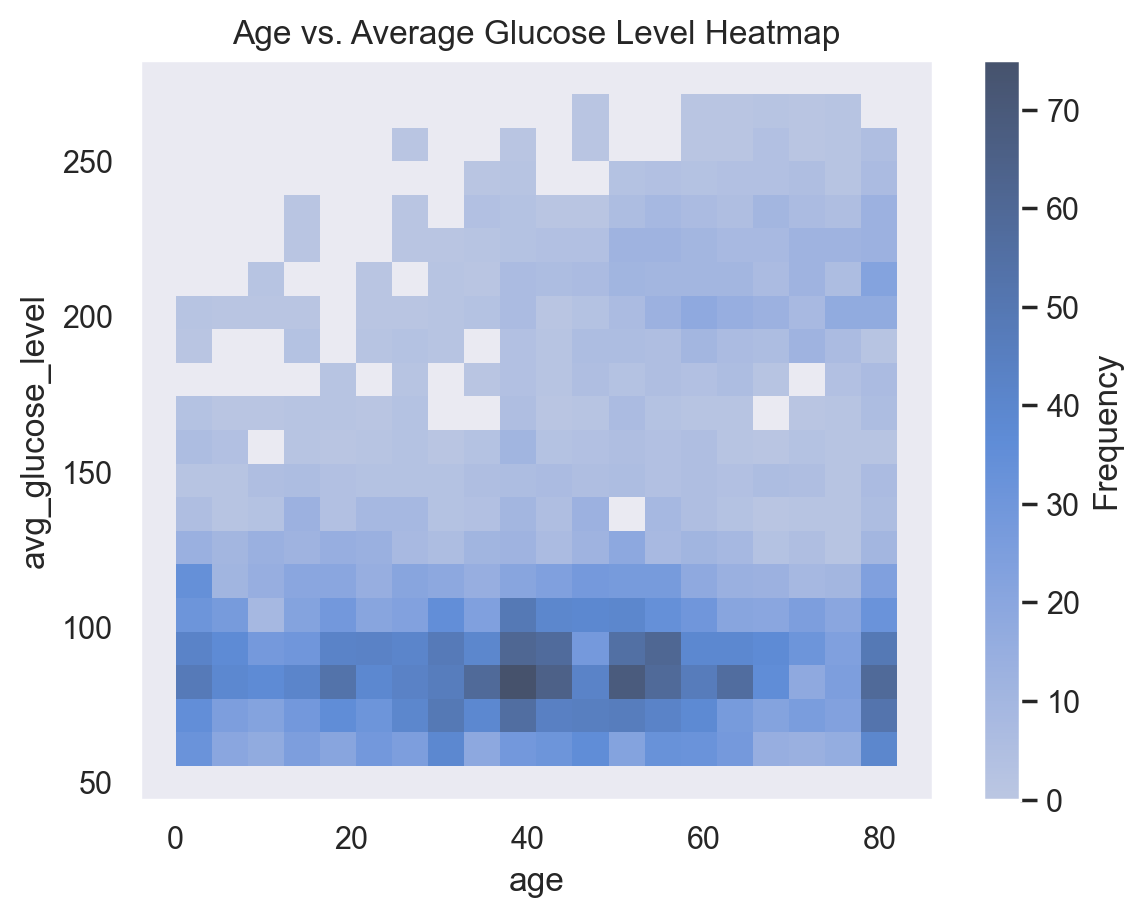

In [37]:
# Recreate the heat map without heart_disease grouping and include a frequency color bar
ax = sns.histplot(
    x='age',
    y='avg_glucose_level',
    data=df,
    bins=20,
    cbar=True,
    cbar_kws={'label': 'Frequency'}
)
ax.set_title('Age vs. Average Glucose Level Heatmap')
plt.show()

### Research Questions

include F-Statistic